<a href="https://colab.research.google.com/github/mw2304/SummerProject2026/blob/main/newMLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install awkward_pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 990.1/990.1 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.8/698.8 kB 54.8 MB/s eta 0:00:00


In [2]:
%pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 12.3 MB/s eta 0:00:00


In [3]:
#imports

import numpy as np
import pandas as pd
import uproot
import awkward as ak
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
ROOT_FILE = "augmerged.root"

file = uproot.open(ROOT_FILE)

print(file.keys())

tree = file["ThreeG_NCS"]
print(tree.keys())

['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']
['RunID', 'EventID', 'NGammas', 'AnnihilX_mm', 'AnnihilY_mm', 'AnnihilZ_mm', 'GammaIndex', 'GammaTrackID', 'GammaParentID', 'HitIndex', 'VolumeID', 'VolumeName', 'ProcessID', 'ProcessName', 'EnergyDeposit_keV', 'PreEnergy_keV', 'PostEnergy_keV', 'X_mm', 'Y_mm', 'Z_mm', 'Theta_deg', 'Phi_deg', 'DeltaPhi01_deg', 'DeltaPhi02_deg', 'DeltaPhi12_deg']


In [5]:
branches = [

    "RunID",
    "EventID",

    "GammaIndex",
    'NGammas',

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head())

              RunID  EventID  GammaIndex  NGammas       X_mm       Y_mm  \
0  slurm_36283167_1       43           0        3  22.533781  45.725643   
1  slurm_36283167_1       43           1        3 -19.154974 -41.295967   
2  slurm_36283167_1       43           2        3  10.009033  22.802109   
3  slurm_36283167_1       56           0        3  15.187184  14.526692   
4  slurm_36283167_1       56           1        3   1.183054 -10.753192   

        Z_mm  EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  \
0  -6.039716         187.380234     187.380234             0.0     3.079860   
1  42.954437         471.598907     471.598907             0.0     3.079860   
2 -44.240387         363.018677     363.018677             0.0     3.079860   
3  46.622974         492.708618     492.708618             0.0    -0.369778   
4 -51.622868         304.623718     304.623718             0.0    -0.369778   

   AnnihilY_mm  AnnihilZ_mm  
0     6.565360    -6.969770  
1     6.565360

In [6]:
# Get unique events
events = df[["RunID", "EventID"]].drop_duplicates()

# Select the first 15000 events
events_15000 = events.head(15000)

print("Number of events selected:", len(events_15000))

Number of events selected: 15000


In [7]:
df_15000 = df.merge(
    events_15000,
    on=["RunID", "EventID"],
    how="inner"
)

print("Number of rows:", len(df_15000))
print(
    "Number of events:",
    df_15000.groupby(["RunID", "EventID"]).ngroups
)

Number of rows: 45000
Number of events: 15000


In [9]:
# ==========================================
# POSITION + ENERGY + GEOMETRIC FEATURES
# ==========================================

event_features = []
event_targets = []

for (run_id, event_id), event in df_15000.groupby(
    ["RunID", "EventID"]
):

    # Keep gamma ordering consistent
    event = event.sort_values("GammaIndex")

    if len(event) < 3:
        continue

    event = event.iloc[:3]

    # --------------------------------------
    # Extract positions and energies
    # --------------------------------------

    hit1 = event.iloc[0][["X_mm", "Y_mm", "Z_mm"]].values.astype(float)
    hit2 = event.iloc[1][["X_mm", "Y_mm", "Z_mm"]].values.astype(float)
    hit3 = event.iloc[2][["X_mm", "Y_mm", "Z_mm"]].values.astype(float)

    e1 = float(event.iloc[0]["EnergyDeposit_keV"])
    e2 = float(event.iloc[1]["EnergyDeposit_keV"])
    e3 = float(event.iloc[2]["EnergyDeposit_keV"])

    # --------------------------------------
    # Pairwise distances
    # --------------------------------------

    d12 = np.linalg.norm(hit1 - hit2)
    d13 = np.linalg.norm(hit1 - hit3)
    d23 = np.linalg.norm(hit2 - hit3)

    # --------------------------------------
    # 15 INPUT FEATURES
    # --------------------------------------

    features = np.concatenate([
        hit1, [e1],
        hit2, [e2],
        hit3, [e3],
        [d12, d13, d23]
    ])

    event_features.append(features)

    # --------------------------------------
    # Target
    # --------------------------------------

    target = event[
        ["AnnihilX_mm", "AnnihilY_mm", "AnnihilZ_mm"]
    ].iloc[0].values.astype(float)

    event_targets.append(target)


X = np.array(event_features)
y = np.array(event_targets)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15000, 15)
y shape: (15000, 3)


In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.33,
    random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

# Input scaler
input_scaler = StandardScaler()

X_train_scaled = input_scaler.fit_transform(X_train)
X_val_scaled = input_scaler.transform(X_val)
X_test_scaled = input_scaler.transform(X_test)


# Target scaler
target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(y_train)
y_val_scaled = target_scaler.transform(y_val)
y_test_scaled = target_scaler.transform(y_test)

In [12]:
# ==========================================
# MLP: POSITION + ENERGY + DISTANCES
# ==========================================

model = tf.keras.Sequential([

    # 15 inputs:
    # X1 Y1 Z1 E1
    # X2 Y2 Z2 E2
    # X3 Y3 Z3 E3
    # d12 d13 d23
    tf.keras.layers.Input(shape=(15,)),

    # Hidden layer 1
    tf.keras.layers.Dense(
        100,
        activation="relu"
    ),

    # Hidden layer 2
    tf.keras.layers.Dense(
        100,
        activation="relu"
    ),

    # Output: predicted X, Y, Z
    tf.keras.layers.Dense(3)
])


# ==========================================
# COMPILE
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mae",
    metrics=["mae"]
)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,003 (46.89 KB)

 Trainable params: 12,003 (46.89 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ==========================================
# TRAIN MLP
# ==========================================

history = model.fit(

    X_train_scaled,
    y_train_scaled,

    validation_data=(
        X_val_scaled,
        y_val_scaled
    ),

    epochs=100,
    batch_size=32,

    verbose=1
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.8355 - mae: 0.8355 - val_loss: 0.7977 - val_mae: 0.7977
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7912 - mae: 0.7912 - val_loss: 0.7618 - val_mae: 0.7618
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7460 - mae: 0.7460 - val_loss: 0.7166 - val_mae: 0.7166
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7042 - mae: 0.7042 - val_loss: 0.6925 - val_mae: 0.6925
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6711 - mae: 0.6711 - val_loss: 0.6656 - val_mae: 0.6656
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6484 - mae: 0.6484 - val_loss: 0.6516 - val_mae: 0.6516
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6260 - mae: 0.6260 - val_loss: 0.6267 - val_mae: 0.6267
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6085 - mae: 0.6085 - val_loss: 0.6087 - val_mae: 0.6087
Epoch 9/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/

In [14]:

y_pred_scaled = model(
    X_test_scaled,
    training=False
).numpy()

# Convert predictions back to mm
y_pred = target_scaler.inverse_transform(
    y_pred_scaled
)

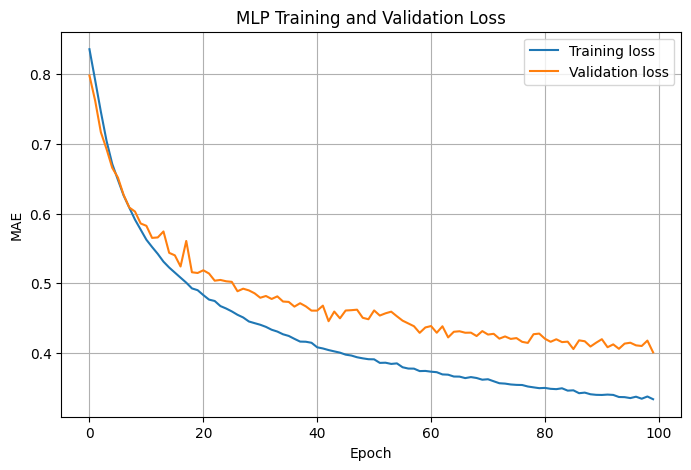

In [15]:
#trainign curve - loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
#reconstuction error
errors = np.sqrt(
    (y_pred[:, 0] - y_test[:, 0])**2 +
    (y_pred[:, 1] - y_test[:, 1])**2 +
    (y_pred[:, 2] - y_test[:, 2])**2
)

mean_error = np.mean(errors)
median_error = np.median(errors)

x_mae = np.mean(
    np.abs(y_pred[:, 0] - y_test[:, 0])
)

y_mae = np.mean(
    np.abs(y_pred[:, 1] - y_test[:, 1])
)

z_mae = np.mean(
    np.abs(y_pred[:, 2] - y_test[:, 2])
)


print(f"Mean error   : {mean_error:.3f} mm")
print(f"Median error : {median_error:.3f} mm")
print(f"X MAE        : {x_mae:.3f} mm")
print(f"Y MAE        : {y_mae:.3f} mm")
print(f"Z MAE        : {z_mae:.3f} mm")

Mean error   : 1.674 mm
Median error : 1.498 mm
X MAE        : 0.827 mm
Y MAE        : 0.886 mm
Z MAE        : 0.794 mm


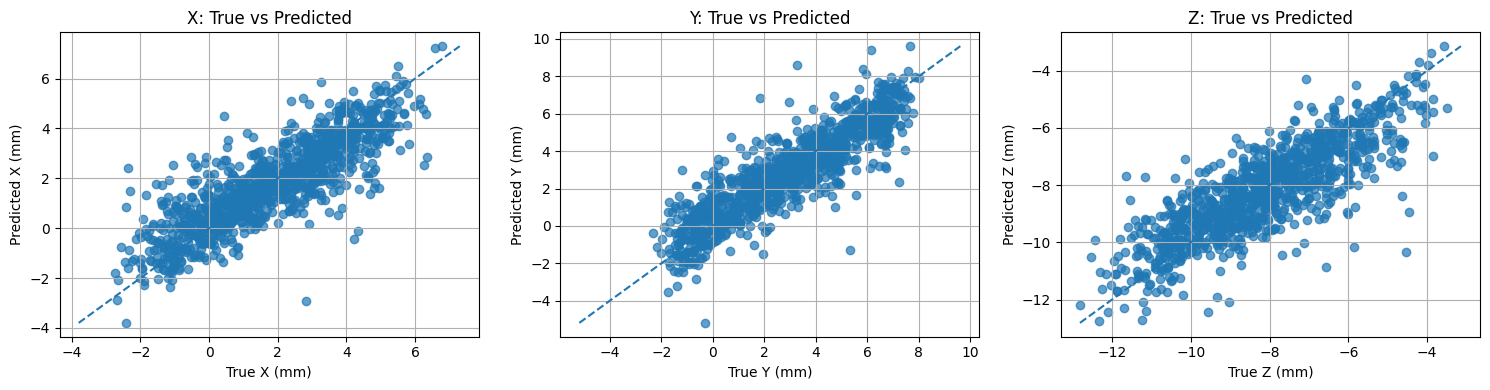

In [17]:

# TRUE VS PREDICTED X/Y/Z


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

coordinates = ["X", "Y", "Z"]

for i, coord in enumerate(coordinates):

    axes[i].scatter(
        y_test[:, i],
        y_pred[:, i],
        alpha=0.7
    )

    # Perfect prediction line
    minimum = min(
        y_test[:, i].min(),
        y_pred[:, i].min()
    )

    maximum = max(
        y_test[:, i].max(),
        y_pred[:, i].max()
    )

    axes[i].plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    axes[i].set_xlabel(f"True {coord} (mm)")
    axes[i].set_ylabel(f"Predicted {coord} (mm)")
    axes[i].set_title(f"{coord}: True vs Predicted")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

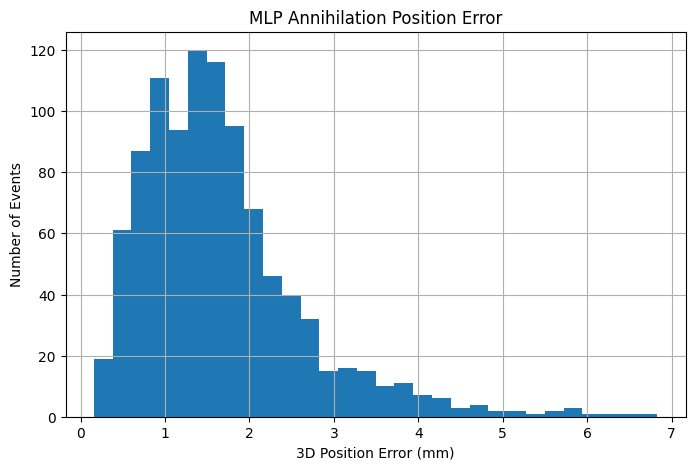

In [18]:
#RECONSTRUCTION ERROR DIST.

plt.figure(figsize=(8, 5))

plt.hist(errors, bins=30)

plt.xlabel("3D Position Error (mm)")
plt.ylabel("Number of Events")
plt.title("MLP Annihilation Position Error")

plt.grid(True)

plt.show()

In [20]:
#COMPARING TO BASELINE OF DEFAULTING TO MEAN

# Calculate the mean annihilation position
# using TRAINING data only
mean_position = np.mean(y_train, axis=0)

print("Mean annihilation position:")
print(f"X = {mean_position[0]:.3f} mm")
print(f"Y = {mean_position[1]:.3f} mm")
print(f"Z = {mean_position[2]:.3f} mm")


# Predict the same position for every test event
mean_predictions = np.tile(
    mean_position,
    (len(y_test), 1)
)


# ==========================================
# 3D ERROR FOR MEAN BASELINE
# ==========================================

mean_errors = np.sqrt(
    (mean_predictions[:, 0] - y_test[:, 0])**2 +
    (mean_predictions[:, 1] - y_test[:, 1])**2 +
    (mean_predictions[:, 2] - y_test[:, 2])**2
)

mean_3d_error = np.mean(mean_errors)
mean_median_error = np.median(mean_errors)

print("\n======================================")
print("MEAN POSITION BASELINE")
print("======================================")

print(f"Mean 3D error   : {mean_3d_error:.3f} mm")
print(f"Median 3D error : {mean_median_error:.3f} mm")
print(f"Maximum error   : {np.max(mean_errors):.3f} mm")


# ==========================================
# MLP VS MEAN BASELINE
# ==========================================

mlp_errors = np.sqrt(
    (y_pred[:, 0] - y_test[:, 0])**2 +
    (y_pred[:, 1] - y_test[:, 1])**2 +
    (y_pred[:, 2] - y_test[:, 2])**2
)

print("\n======================================")
print("MLP VS MEAN BASELINE")
print("======================================")

print(f"MLP mean 3D error  : {np.mean(mlp_errors):.3f} mm")
print(f"Mean baseline      : {np.mean(mean_errors):.3f} mm")

improvement = (
    (np.mean(mean_errors) - np.mean(mlp_errors))
    / np.mean(mean_errors)
    * 100
)

print(f"Improvement        : {improvement:.1f}%")


Mean annihilation position:
X = 1.825 mm
Y = 3.000 mm
Z = -8.142 mm

MEAN POSITION BASELINE
Mean 3D error   : 3.548 mm
Median 3D error : 3.669 mm
Maximum error   : 6.416 mm

MLP VS MEAN BASELINE
MLP mean 3D error  : 1.674 mm
Mean baseline      : 3.548 mm
Improvement        : 52.8%


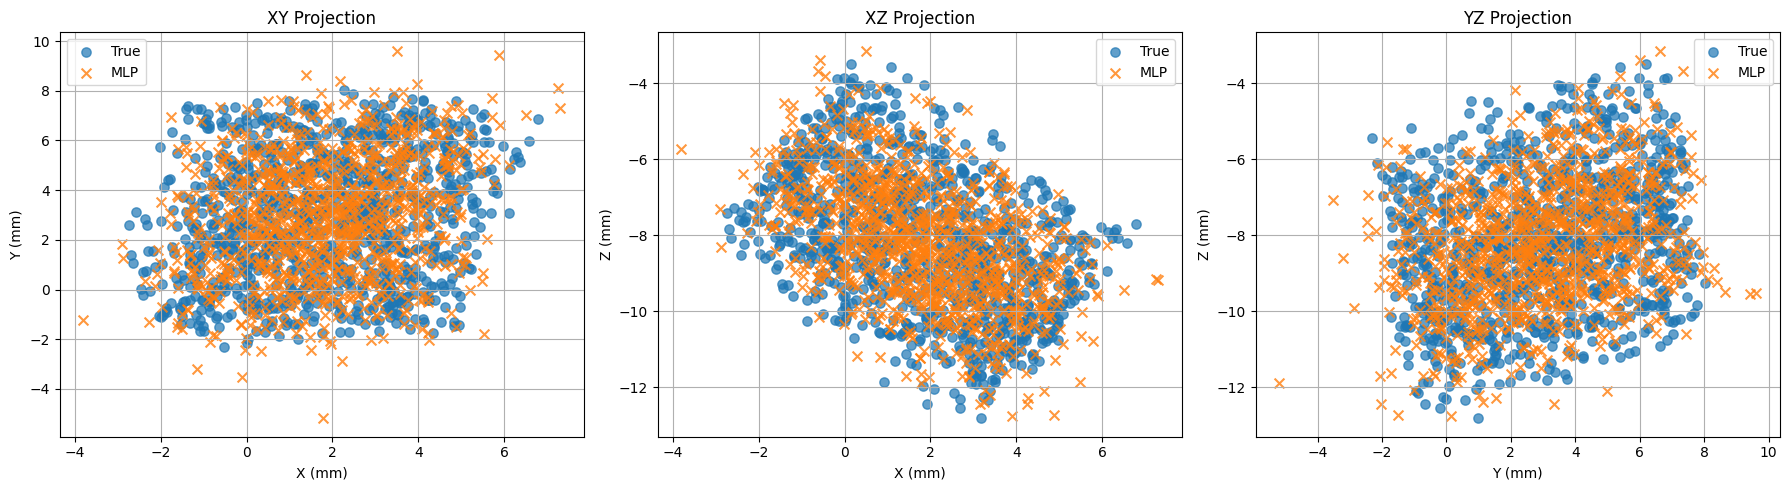

In [21]:
#2D PROJECTION

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5)
)

# ------------------------------------------
# XY
# ------------------------------------------

axes[0].scatter(
    y_test[:, 0],
    y_test[:, 1],
    marker="o",
    s=45,
    alpha=0.7,
    label="True"
)

axes[0].scatter(
    y_pred[:, 0],
    y_pred[:, 1],
    marker="x",
    s=50,
    alpha=0.8,
    label="MLP"
)

axes[0].set_xlabel("X (mm)")
axes[0].set_ylabel("Y (mm)")
axes[0].set_title("XY Projection")
axes[0].legend()
axes[0].grid(True)


# ------------------------------------------
# XZ
# ------------------------------------------

axes[1].scatter(
    y_test[:, 0],
    y_test[:, 2],
    marker="o",
    s=45,
    alpha=0.7,
    label="True"
)

axes[1].scatter(
    y_pred[:, 0],
    y_pred[:, 2],
    marker="x",
    s=50,
    alpha=0.8,
    label="MLP"
)

axes[1].set_xlabel("X (mm)")
axes[1].set_ylabel("Z (mm)")
axes[1].set_title("XZ Projection")
axes[1].legend()
axes[1].grid(True)


# ------------------------------------------
# YZ
# ------------------------------------------

axes[2].scatter(
    y_test[:, 1],
    y_test[:, 2],
    marker="o",
    s=45,
    alpha=0.7,
    label="True"
)

axes[2].scatter(
    y_pred[:, 1],
    y_pred[:, 2],
    marker="x",
    s=50,
    alpha=0.8,
    label="MLP"
)

axes[2].set_xlabel("Y (mm)")
axes[2].set_ylabel("Z (mm)")
axes[2].set_title("YZ Projection")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()